# SYNAPSE 2026 — National Data Analyst Case Competition
## Optimasi Transformasi "Smart Hospital" dan Efisiensi Operasional Rumah Sakit

**Peserta:** Joyce Stephanie Naibaho
**Program Studi:** Informatika, Institut Teknologi Del, Sumatera Utara
**Kompetisi:** National Data Analyst Case Competition — SYNAPSE 2026 (HIMSI Universitas Lamappapoleonro)

---

### Tujuan Analisis
Sebagai Senior Data Analyst yang disewa oleh Konsorsium Smart Hospital Nusantara, notebook ini membedah dataset operasional dan metrik digital 276 rumah sakit di Indonesia untuk menjawab tiga pilar pertanyaan strategis:

1. **Audit Kematangan Digital & Investasi** — profil kesiapan digital, ketimpangan antar kelas/kepemilikan RS, dan korelasi anggaran IT dengan skor kematangan digital.
2. **Evaluasi Dampak Operasional** — apakah kematangan digital & konektivitas SatuSehat benar-benar meningkatkan efisiensi operasional (waktu respons rujukan, volume telemedicine).
3. **Identifikasi Bottleneck** — menemukan RS dengan "inefisiensi ganda" (skor digital rendah + beban operasional tinggi) sebagai prioritas intervensi.


### Daftar Isi
1. [Data Loading & Data Quality Check](#1.-Data-Loading-&-Data-Quality-Check)
2. [Exploratory Data Analysis (EDA)](#2.-Exploratory-Data-Analysis-(EDA))
3. [Pilar A — Audit Kematangan Digital & Investasi](#3.-Pilar-A-—-Audit-Kematangan-Digital-&-Investasi)
4. [Pilar B — Evaluasi Dampak Operasional](#4.-Pilar-B-—-Evaluasi-Dampak-Operasional)
5. [Pilar C — Identifikasi Bottleneck (Inefisiensi Ganda)](#5.-Pilar-C-—-Identifikasi-Bottleneck-(%22Inefisiensi-Ganda%22))
6. [Analisis Tambahan — Disparitas Wilayah](#5b.-Analisis-Tambahan-—-Disparitas-Wilayah-(Barat-vs-Timur-Indonesia))
7. [Ringkasan Insight, Rekomendasi & Kesimpulan](#6.-Ringkasan-Insight,-Rekomendasi-Strategis-&-Kesimpulan)
8. [Executive Takeaways](#Executive-Takeaways)

*Catatan: navigasi tautan di atas bekerja di Jupyter/JupyterLab. Jika dibuka di viewer lain dan tautan tidak aktif, gunakan judul section sebagai acuan scroll manual.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Catatan reproducibility: tidak ada proses sampling/randomisasi di pipeline analisis ini
# (seluruh langkah -- cleaning, korelasi, ANOVA, uji-t -- bersifat deterministik terhadap data).
# Seed tetap ditetapkan sebagai praktik baik, berjaga-jaga jika ada eksperimen acak di iterasi berikutnya.
np.random.seed(42)

# Palet warna konsisten untuk seluruh visualisasi
NAVY, TEAL, CORAL, GOLD, GREEN, GRAY, LIGHTGRAY = \
    "#0B3D5C", "#1C8C8C", "#E4572E", "#E8A33D", "#3FA796", "#9AA5B1", "#E7EAEE"

plt.rcParams.update({
    'font.size': 11, 'axes.grid': True, 'grid.color': LIGHTGRAY,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': '#1A1A1A', 'axes.labelcolor': '#1A1A1A',
    'xtick.color': '#1A1A1A', 'ytick.color': '#1A1A1A',
})

### Fungsi Bantu

Dua pola visualisasi berulang di seluruh notebook ini (scatter+regresi untuk uji korelasi, dan bar chart perbandingan kelompok) dibungkus jadi fungsi agar kode tidak duplikatif dan lebih mudah diaudit.

In [2]:
def scatter_with_corr(x, y, xlabel, ylabel, title, color=TEAL, figsize=(9, 5)):
    """Scatter plot + garis regresi linear; judul otomatis menampilkan koefisien korelasi Pearson.
    Return: (r, p) -- koefisien korelasi dan p-value, agar bisa dipakai lagi untuk narasi/insight."""
    r, p = stats.pearsonr(x, y)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, s=35, alpha=0.5, color=color, edgecolor=NAVY, linewidth=0.3)
    z = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.polyval(z, xline), color=CORAL, linewidth=2.5)
    ax.set_title(f'{title} (r={r:.2f})', fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    plt.tight_layout(); plt.show()
    return r, p


def barplot_compare(ax, labels, values, colors, title, ylabel=None, ylim=None, value_fmt='{:.1f}'):
    """Bar chart sederhana dengan label nilai di atas tiap bar -- dipakai untuk semua perbandingan
    2-4 kelompok (mis. SatuSehat Ya/Tidak, skor digital Rendah/Tinggi, Barat/Timur)."""
    ax.bar(labels, values, color=colors, edgecolor='white', width=0.55)
    headroom = (max(values) - min(min(values), 0)) * 0.06 or 1
    for i, v in enumerate(values):
        ax.text(i, v + headroom, value_fmt.format(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold', color='#1A1A1A')
    if ylabel:
        ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)


def boxplot_group(ax, data, group_col, value_col, order, colors, title, ylabel):
    """Boxplot untuk membandingkan SEBARAN (bukan cuma rata-rata) suatu nilai numerik antar
    kelompok kategorikal -- menampilkan median, IQR, dan outlier sekaligus, lebih informatif
    dibanding bar chart rata-rata saja untuk data yang variansnya besar antar kelompok."""
    groups = [data[data[group_col] == g][value_col].dropna().values for g in order]
    bp = ax.boxplot(groups, tick_labels=order, patch_artist=True, widths=0.55,
                     medianprops=dict(color='#1A1A1A', linewidth=2),
                     flierprops=dict(marker='o', markersize=4, markerfacecolor='#6B7684',
                                      markeredgecolor='none', alpha=0.6))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('white')
    ax.set_title(title, fontweight='bold', color='#1A1A1A')
    ax.set_ylabel(ylabel)

## 1. Data Loading & Data Quality Check

Dataset berisi 276 rumah sakit dengan 20 variabel mencakup profil RS, metrik operasional (BOR, LOS, kunjungan pasien, waktu respons rujukan), dan metrik digital (skor kematangan digital, status RME/SatuSehat, anggaran & staf IT, perangkat IoT, kunjungan telemedicine).

In [3]:
import os, glob

# Notebook ini mencari file dataset secara fleksibel -- coba beberapa nama umum dulu,
# lalu fallback ke pencarian file .csv apa pun di folder yang sama jika tidak ketemu.
# Jika dataset diletakkan panitia dengan nama berbeda, cukup taruh di folder yang sama
# dengan notebook ini (atau ubah `possible_names` di bawah).
possible_names = [
    'dataset_smart_hospital_indonesia.csv',
    'dataset_smart_hospital_indonesia (1).csv',
    'dataset_smart_hospital_indonesia__1_.csv',
    '../data/dataset_smart_hospital_indonesia.csv',  # struktur repo GitHub: notebooks/ + data/
    'data/dataset_smart_hospital_indonesia.csv',
]
csv_path = next((n for n in possible_names if os.path.exists(n)), None)

if csv_path is None:
    candidates = (glob.glob('*smart_hospital*.csv') or glob.glob('**/*smart_hospital*.csv', recursive=True)
                  or glob.glob('*.csv') or glob.glob('data/*.csv') or glob.glob('../data/*.csv'))
    csv_path = candidates[0] if candidates else None

if csv_path is None:
    # Dataset belum ada di folder kerja. Jika dijalankan di Google Colab, munculkan dialog
    # upload interaktif alih-alih langsung error -- supaya user tinggal pilih filenya.
    try:
        from google.colab import files  # hanya berhasil di-import jika berjalan di Google Colab
        print("Dataset tidak ditemukan di folder kerja. Silakan upload file CSV dataset (mis. "
              "'dataset_smart_hospital_indonesia.csv') melalui dialog berikut:")
        uploaded = files.upload()
        csv_path = next(iter(uploaded)) if uploaded else None
    except ImportError:
        pass  # bukan Colab -- lanjut ke pesan error manual di bawah

if csv_path is None:
    raise FileNotFoundError(
        "Dataset CSV tidak ditemukan di folder ini. Pastikan file dataset (mis. "
        "'dataset_smart_hospital_indonesia.csv') sudah diunggah/diletakkan di folder yang sama "
        "dengan notebook ini (folder kerja saat ini: " + os.getcwd() + "), lalu jalankan ulang cell ini."
    )

print(f"Menggunakan dataset: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Jumlah RS: {len(df)} | Jumlah kolom: {df.shape[1]}")
print(f"Shape: {df.shape}")
df.info()

Menggunakan dataset: dataset_smart_hospital_indonesia.csv
Jumlah RS: 276 | Jumlah kolom: 20
Shape: (276, 20)
<class 'pandas.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id_rumah_sakit                          276 non-null    str    
 1   nama_rumah_sakit                        276 non-null    str    
 2   provinsi                                276 non-null    str    
 3   kota_kabupaten                          276 non-null    str    
 4   kelas_rumah_sakit                       276 non-null    str    
 5   kepemilikan                             276 non-null    str    
 6   jumlah_tempat_tidur                     276 non-null    int64  
 7   jumlah_jenis_layanan                    276 non-null    int64  
 8   jumlah_tenaga_kerja                     276 non-null    int64  
 9   tingkat_keterisian_tempat_tidur_p

In [4]:
df.head()

,id_rumah_sakit,nama_rumah_sakit,provinsi,kota_kabupaten,kelas_rumah_sakit,kepemilikan,jumlah_tempat_tidur,jumlah_jenis_layanan,jumlah_tenaga_kerja,tingkat_keterisian_tempat_tidur_persen,rata_rata_lama_rawat_hari,kunjungan_pasien_per_bulan,status_implementasi_rme,status_terhubung_satusehat,skor_kematangan_digital,kunjungan_telemedicine_per_bulan,jumlah_perangkat_iot,jumlah_staf_it,anggaran_it_tahunan_juta_rupiah,rata_rata_waktu_respons_rujukan_menit
0,RS0001,RS Bunda Kasih 1,DKI Jakarta,Kota Cempaka,C,Swasta,61,16,390,54.6,5.3,796,Ya,Ya,77.8,262.0,65,4.0,169.3,24.1
1,RS0002,RS Graha Sehat 2,DKI Jakarta,Kota Bukitraya,D,TNI/POLRI,54,8,171,56.5,5.0,709,Ya,Tidak,74.3,139.0,52,5.0,132.8,25.7
2,RS0003,RSUD Bhakti Husada 3,DKI Jakarta,Kab. Sukajadi,D,Pemerintah Daerah,73,10,159,81.6,2.0,1071,Ya,Ya,72.9,211.0,44,8.0,129.6,51.2
3,RS0004,RSUD Harapan Bangsa 4,DKI Jakarta,Kab. Tanjungsari,C,Pemerintah Daerah,106,17,278,74.4,3.3,889,Ya,Ya,66.7,156.0,43,6.0,132.3,17.7
4,RS0005,RSUD Karya Insani 5,DKI Jakarta,Kota Sukajadi,C,Pemerintah Daerah,134,12,393,86.2,3.7,1628,Ya,Ya,73.8,90.0,67,4.0,143.3,35.1


In [5]:
print("=== Missing values ===")
print(df.isna().sum()[df.isna().sum() > 0])
print("\n=== Duplikat ID ===", df['id_rumah_sakit'].duplicated().sum())
print("\n=== Nilai unik kelas_rumah_sakit (sebelum dibersihkan) ===")
print(df['kelas_rumah_sakit'].unique())
print("\n=== Nilai unik kepemilikan (sebelum dibersihkan) ===")
print(df['kepemilikan'].unique())

=== Missing values ===
kunjungan_telemedicine_per_bulan    8
jumlah_staf_it                      8
anggaran_it_tahunan_juta_rupiah     8
dtype: int64

=== Duplikat ID === 0

=== Nilai unik kelas_rumah_sakit (sebelum dibersihkan) ===
<StringArray>
['C', 'D', 'B', ' B', 'A', 'D ', 'c ']
Length: 7, dtype: str

=== Nilai unik kepemilikan (sebelum dibersihkan) ===
<StringArray>
['Swasta', 'TNI/POLRI', 'Pemerintah Daerah', ' TNI/POLRI', 'Pemerintah Pusat', ' BUMN', 'SWASTA', 'BUMN', ' Swasta']
Length: 9, dtype: str


**Temuan data quality:**
- `kelas_rumah_sakit` dan `kepemilikan` punya inkonsistensi whitespace & kapitalisasi (mis. `' B'`, `'D '`, `'c '`, `'SWASTA'` vs `'Swasta'`) → perlu distandardisasi, bukan dianggap kategori berbeda.
- 8 RS (2.9%) tidak melaporkan `jumlah_staf_it`, `anggaran_it_tahunan_juta_rupiah`, dan `kunjungan_telemedicine_per_bulan` → dikecualikan hanya pada analisis yang melibatkan kolom tsb.
- RS0188 (kelas C) tercatat memiliki **3.200 tempat tidur** — jauh di luar kewajaran kelas C Indonesia (rata-rata kelas C lain ±114 bed). Ini kemungkinan besar *data entry error* dan diperlakukan sebagai outlier di analisis berbasis tempat tidur.
- Tiga nilai mustahil/ekstrem lolos pada variabel penyusun Indeks Beban Operasional (dihitung di Bagian 5) — **jika tidak dikoreksi, akan mendistorsi standar deviasi dan komposit z-score**: RS0084 lama rawat inap −2,0 hari (mustahil, negatif), RS0272 waktu respons rujukan 0 menit (implausible untuk proses antar-fasilitas), dan RS0076 BOR 134,6% (outlier ekstrem, gap 35+ poin dari RS lain).

In [6]:
# Data cleaning
df['kelas_rumah_sakit'] = df['kelas_rumah_sakit'].str.strip().str.upper()
df['kepemilikan'] = df['kepemilikan'].str.strip().replace({'SWASTA': 'Swasta'})

print("Setelah dibersihkan:")
print(df['kelas_rumah_sakit'].value_counts())
print()
print(df['kepemilikan'].value_counts())

Setelah dibersihkan:
kelas_rumah_sakit
C    113
D     74
B     73
A     16
Name: count, dtype: int64

kepemilikan
Swasta               112
Pemerintah Daerah    101
TNI/POLRI             28
Pemerintah Pusat      24
BUMN                  11
Name: count, dtype: int64


### Koreksi Nilai Mustahil/Ekstrem pada Variabel Penyusun Indeks Beban Operasional

Sebelum Indeks Beban Operasional dihitung di Bagian 5, tiga nilai berikut dikoreksi (winsorize ke nilai valid terdekat) karena secara fisik mustahil atau berpotensi mendominasi z-score komposit secara tidak proporsional:

In [7]:
extreme_fixes = []

# RS0084: LOS = -2.0 hari (mustahil, negatif) -> nilai valid terendah berikutnya
mask_los = df['rata_rata_lama_rawat_hari'] < 0
if mask_los.any():
    rs_id = df.loc[mask_los, 'id_rumah_sakit'].values[0]
    old_val = df.loc[mask_los, 'rata_rata_lama_rawat_hari'].values[0]
    next_valid = df.loc[~mask_los, 'rata_rata_lama_rawat_hari'].min()
    extreme_fixes.append(f"{rs_id}: LOS {old_val} hari (mustahil, negatif) -> dikoreksi ke {next_valid}")
    df.loc[mask_los, 'rata_rata_lama_rawat_hari'] = next_valid

# RS0272: waktu respons rujukan = 0 menit (implausible) -> nilai valid terendah berikutnya
mask_resp = df['rata_rata_waktu_respons_rujukan_menit'] <= 0
if mask_resp.any():
    rs_id = df.loc[mask_resp, 'id_rumah_sakit'].values[0]
    old_val = df.loc[mask_resp, 'rata_rata_waktu_respons_rujukan_menit'].values[0]
    next_valid = df.loc[~mask_resp, 'rata_rata_waktu_respons_rujukan_menit'].min()
    extreme_fixes.append(f"{rs_id}: waktu respons {old_val} menit (implausible) -> dikoreksi ke {next_valid}")
    df.loc[mask_resp, 'rata_rata_waktu_respons_rujukan_menit'] = next_valid

# RS0076: BOR = 134.6% -- gap 35+ poin dari nilai tertinggi berikutnya -> dicap ke nilai tertinggi berikutnya
mask_bor = df['tingkat_keterisian_tempat_tidur_persen'] > 110
if mask_bor.any():
    rs_id = df.loc[mask_bor, 'id_rumah_sakit'].values[0]
    old_val = df.loc[mask_bor, 'tingkat_keterisian_tempat_tidur_persen'].values[0]
    next_valid = df.loc[~mask_bor, 'tingkat_keterisian_tempat_tidur_persen'].max()
    extreme_fixes.append(f"{rs_id}: BOR {old_val}% (outlier ekstrem) -> dicap ke {next_valid}")
    df.loc[mask_bor, 'tingkat_keterisian_tempat_tidur_persen'] = next_valid

print("Koreksi yang diterapkan:")
for f in extreme_fixes:
    print(f"- {f}")

Koreksi yang diterapkan:
- RS0084: LOS -2.0 hari (mustahil, negatif) -> dikoreksi ke 1.5
- RS0272: waktu respons 0.0 menit (implausible) -> dikoreksi ke 5.0
- RS0076: BOR 134.6% (outlier ekstrem) -> dicap ke 99.0


Koreksi ini tidak mengubah temuan headline (disparitas wilayah, non-signifikansi status SatuSehat) — namun memperkuat validitas Indeks Beban Operasional dan mencegah kesalahan klasifikasi RS di analisis kuadran bottleneck.

## 2. Exploratory Data Analysis (EDA)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
jumlah_tempat_tidur,276.0,156.902174,208.549382,29.0,76.750,119.50,182.25,3200.0
jumlah_jenis_layanan,276.0,15.615942,6.821168,5.0,11.000,14.00,20.00,35.0
jumlah_tenaga_kerja,276.0,402.775362,255.099040,86.0,201.000,339.00,524.25,1437.0
tingkat_keterisian_tempat_tidur_persen,276.0,67.913043,12.758580,36.5,59.175,67.25,76.30,99.0
rata_rata_lama_rawat_hari,276.0,4.182246,1.340045,1.5,3.300,4.20,5.00,8.7
kunjungan_pasien_per_bulan,276.0,1807.648551,1365.369916,221.0,936.000,1332.00,2267.25,7411.0
skor_kematangan_digital,276.0,57.017029,18.932167,7.3,44.050,57.70,70.20,99.0
kunjungan_telemedicine_per_bulan,268.0,137.600746,70.196415,0.0,95.000,143.00,179.25,323.0
jumlah_perangkat_iot,276.0,33.188406,17.413704,0.0,20.750,31.50,45.00,81.0
jumlah_staf_it,268.0,4.268657,2.300185,0.0,3.000,4.00,6.00,12.0


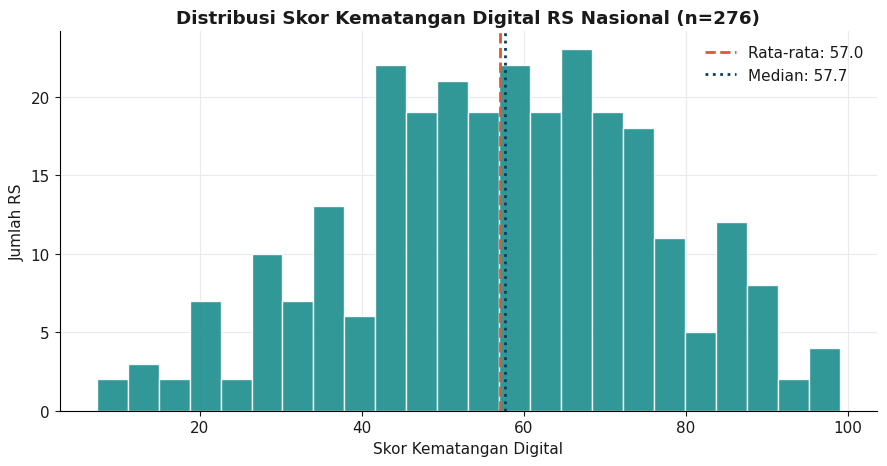

Sebaran skor kematangan digital sangat lebar (std=18.9), rentang 7.3-99.0 -- mengindikasikan kesenjangan digital yang signifikan antar RS.


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(df['skor_kematangan_digital'], bins=24, color=TEAL, edgecolor='white', alpha=0.9)
mean_v, med_v = df['skor_kematangan_digital'].mean(), df['skor_kematangan_digital'].median()
ax.axvline(mean_v, color=CORAL, linestyle='--', linewidth=2, label=f'Rata-rata: {mean_v:.1f}')
ax.axvline(med_v, color=NAVY, linestyle=':', linewidth=2, label=f'Median: {med_v:.1f}')
ax.set_title('Distribusi Skor Kematangan Digital RS Nasional (n=276)', fontweight='bold')
ax.set_xlabel('Skor Kematangan Digital'); ax.set_ylabel('Jumlah RS')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"Sebaran skor kematangan digital sangat lebar (std={df['skor_kematangan_digital'].std():.1f}), "
      f"rentang {df['skor_kematangan_digital'].min():.1f}-{df['skor_kematangan_digital'].max():.1f} -- "
      f"mengindikasikan kesenjangan digital yang signifikan antar RS.")

**Catatan metodologi:** Korelasi Pearson mengasumsikan hubungan linear antar variabel numerik dan idealnya data mendekati distribusi normal. Berikut pengecekan singkat menggunakan uji Shapiro-Wilk pada dua variabel kunci sebelum interpretasi korelasi dilanjutkan.

In [10]:
# Uji normalitas (Shapiro-Wilk) untuk dua variabel kunci sebelum interpretasi korelasi Pearson
stat_sk, p_sk = stats.shapiro(df['skor_kematangan_digital'])
stat_ang, p_ang_norm = stats.shapiro(df['anggaran_it_tahunan_juta_rupiah'].dropna())
print(f"Shapiro-Wilk -- skor_kematangan_digital : W={stat_sk:.4f}, p={p_sk:.4f} --> {'normal (p>=0.05)' if p_sk>=0.05 else 'menyimpang dari normal (p<0.05)'}")
print(f"Shapiro-Wilk -- anggaran_it_tahunan      : W={stat_ang:.4f}, p={p_ang_norm:.4f} --> {'normal (p>=0.05)' if p_ang_norm>=0.05 else 'menyimpang dari normal (p<0.05)'}")
print()
print("Kedua p-value > 0.05, artinya tidak cukup bukti untuk menolak asumsi normalitas -- distribusi kedua")
print("variabel cukup mendekati normal, mendukung penggunaan korelasi Pearson secara langsung tanpa perlu")
print("transformasi data atau beralih ke korelasi non-parametrik (mis. Spearman).")
print()
print("Catatan tambahan: dengan ukuran sampel yang relatif besar (n≈276), Pearson tetap cukup robust")
print("terhadap penyimpangan normalitas ringan sekalipun -- uji Shapiro di atas digunakan sebagai")
print("pemeriksaan awal, sementara linearitas hubungan juga diverifikasi langsung melalui scatter plot")
print("pada setiap analisis korelasi di bagian berikut.")

Shapiro-Wilk -- skor_kematangan_digital : W=0.9924, p=0.1680 --> normal (p>=0.05)
Shapiro-Wilk -- anggaran_it_tahunan      : W=0.9936, p=0.3180 --> normal (p>=0.05)

Kedua p-value > 0.05, artinya tidak cukup bukti untuk menolak asumsi normalitas -- distribusi kedua
variabel cukup mendekati normal, mendukung penggunaan korelasi Pearson secara langsung tanpa perlu
transformasi data atau beralih ke korelasi non-parametrik (mis. Spearman).

Catatan tambahan: dengan ukuran sampel yang relatif besar (n≈276), Pearson tetap cukup robust
terhadap penyimpangan normalitas ringan sekalipun -- uji Shapiro di atas digunakan sebagai
pemeriksaan awal, sementara linearitas hubungan juga diverifikasi langsung melalui scatter plot
pada setiap analisis korelasi di bagian berikut.


## 3. Pilar A — Audit Kematangan Digital & Investasi

**Pertanyaan:** Bagaimana profil kesiapan digital RS saat ini? Apakah ada ketimpangan skor berdasarkan kelas/kepemilikan? Apakah anggaran IT berkorelasi dengan skor kematangan digital?

                   mean   std  count
kelas_rumah_sakit                   
A                  61.2  12.0     16
B                  65.4  19.0     73
C                  55.3  17.7    113
D                  50.5  19.1     74

ANOVA (kelas RS vs skor digital): F=9.00, p=0.00001


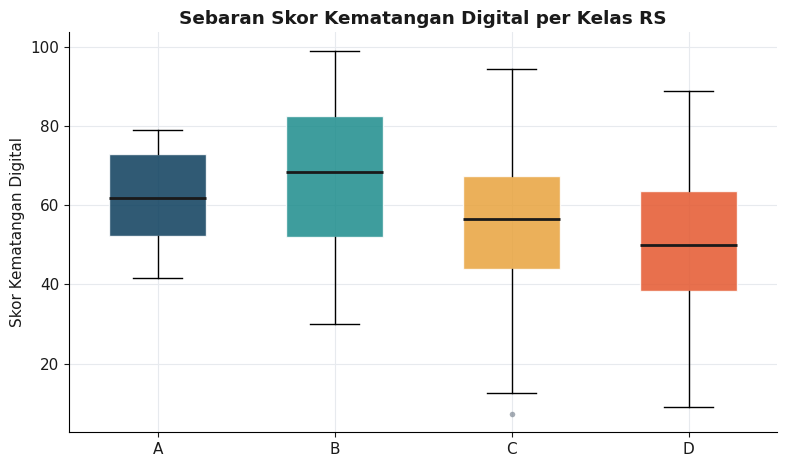

In [11]:
order = ['A','B','C','D']
grp_kelas = df.groupby('kelas_rumah_sakit')['skor_kematangan_digital'].agg(['mean','std','count']).reindex(order)
print(grp_kelas.round(1))

f_kelas, p_kelas = stats.f_oneway(*[df[df['kelas_rumah_sakit']==k]['skor_kematangan_digital'] for k in order])
print(f"\nANOVA (kelas RS vs skor digital): F={f_kelas:.2f}, p={p_kelas:.5f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
boxplot_group(ax, df, group_col='kelas_rumah_sakit', value_col='skor_kematangan_digital', order=order,
              colors=[NAVY, TEAL, GOLD, CORAL], title='Sebaran Skor Kematangan Digital per Kelas RS',
              ylabel='Skor Kematangan Digital')
plt.tight_layout(); plt.show()

In [12]:
grp_own = df.groupby('kepemilikan')['skor_kematangan_digital'].agg(['mean','std','count']).sort_values('mean', ascending=False)
print(grp_own.round(1))

f_own, p_own = stats.f_oneway(*[g['skor_kematangan_digital'] for _, g in df.groupby('kepemilikan')])
print(f"\nANOVA (kepemilikan vs skor digital): F={f_own:.2f}, p={p_own:.5f}  --> {'signifikan' if p_own<0.05 else 'TIDAK signifikan'}")

                   mean   std  count
kepemilikan                         
TNI/POLRI          63.0  16.5     28
Pemerintah Pusat   61.6  18.5     24
BUMN               59.1  16.0     11
Swasta             55.7  20.6    112
Pemerintah Daerah  55.5  17.8    101

ANOVA (kepemilikan vs skor digital): F=1.37, p=0.24630  --> TIDAK signifikan


**Insight:** Gap skor digital antar **kelas RS signifikan** (p<0.001) — namun menariknya kelas **B justru lebih tinggi dari kelas A** (65.4 vs 61.2), bukan tren linear sesuai hierarki kelas. Sebaliknya, gap antar **kepemilikan RS TIDAK signifikan** (p=0.25) — jenis kepemilikan bukan penentu utama kematangan digital.

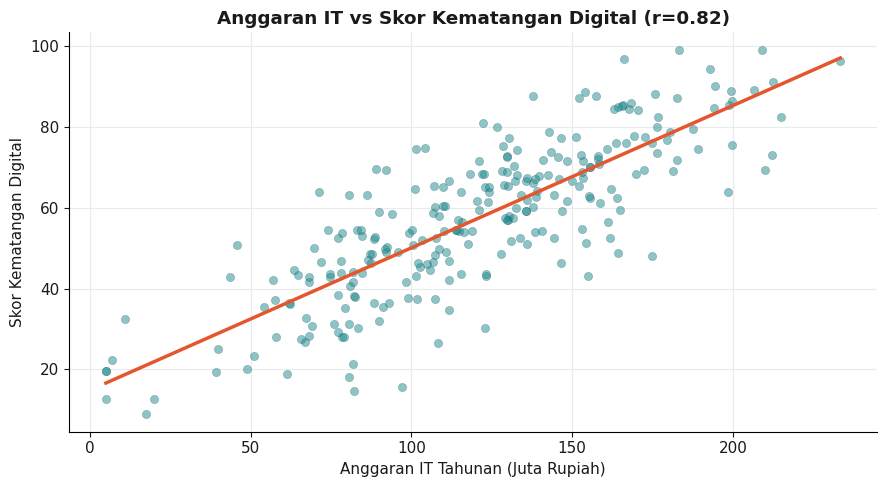

Korelasi anggaran IT vs skor digital   : r=0.816, p=0.00000
Korelasi jumlah staf IT vs skor digital: r=0.534, p=0.00000
Korelasi jumlah IoT vs skor digital     : r=0.652, p=0.00000


In [13]:
sub = df.dropna(subset=['anggaran_it_tahunan_juta_rupiah','skor_kematangan_digital','jumlah_staf_it'])
r_staf, p_staf = stats.pearsonr(sub['jumlah_staf_it'], sub['skor_kematangan_digital'])
r_iot, p_iot = stats.pearsonr(df['jumlah_perangkat_iot'], df['skor_kematangan_digital'])

r_budget, p_budget = scatter_with_corr(
    sub['anggaran_it_tahunan_juta_rupiah'], sub['skor_kematangan_digital'],
    xlabel='Anggaran IT Tahunan (Juta Rupiah)', ylabel='Skor Kematangan Digital',
    title='Anggaran IT vs Skor Kematangan Digital', color=TEAL)

print(f"Korelasi anggaran IT vs skor digital   : r={r_budget:.3f}, p={p_budget:.5f}")
print(f"Korelasi jumlah staf IT vs skor digital: r={r_staf:.3f}, p={p_staf:.5f}")
print(f"Korelasi jumlah IoT vs skor digital     : r={r_iot:.3f}, p={p_iot:.5f}")

**Insight:** Anggaran IT berkorelasi **kuat** dengan skor kematangan digital (r=0.82), jauh lebih kuat dibanding jumlah staf IT (r=0.53) atau jumlah perangkat IoT (r=0.65). Uang saja belum cukup — tapi jadi prediktor terkuat.

In [14]:
sub2 = sub.copy()
sub2['efisiensi_anggaran'] = sub2['skor_kematangan_digital'] / sub2['anggaran_it_tahunan_juta_rupiah']
eff = sub2.groupby('kepemilikan')['efisiensi_anggaran'].mean().sort_values(ascending=False)
print("Efisiensi anggaran (skor digital yang dihasilkan per juta rupiah):")
print(eff.round(4))

Efisiensi anggaran (skor digital yang dihasilkan per juta rupiah):
kepemilikan
Pemerintah Pusat     0.6684
Swasta               0.5747
Pemerintah Daerah    0.5054
TNI/POLRI            0.4817
BUMN                 0.4620
Name: efisiensi_anggaran, dtype: float64


**Catatan metodologi:** rasio skor/anggaran per RS sensitif terhadap RS beranggaran sangat kecil (rasio bisa meledak) dan mengabaikan intercept non-nol. Sebelum menyimpulkan ranking efisiensi ini bermakna, perlu diuji signifikansinya -- bukan cuma dibandingkan sebagai angka deskriptif.

In [15]:
# Uji signifikansi ranking efisiensi (non-parametrik, karena rasio rentan skew)
groups_eff = [g['efisiensi_anggaran'].values for _, g in sub2.groupby('kepemilikan')]
h_stat, p_kw = stats.kruskal(*groups_eff)
print(f"Kruskal-Wallis (efisiensi anggaran antar kepemilikan): H={h_stat:.2f}, p={p_kw:.4f}")

# Alternatif: slope regresi skor~anggaran per kepemilikan (lebih tahan terhadap rasio ekstrem)
print("\nSlope regresi (skor_kematangan_digital ~ anggaran_it) per kepemilikan:")
for k, g in sub2.groupby('kepemilikan'):
    if len(g) >= 5:
        slope, intercept, r, p, se = stats.linregress(g['anggaran_it_tahunan_juta_rupiah'], g['skor_kematangan_digital'])
        print(f"  {k}: slope={slope:.3f} (n={len(g)}, p={p:.4f})")

Kruskal-Wallis (efisiensi anggaran antar kepemilikan): H=6.36, p=0.1738

Slope regresi (skor_kematangan_digital ~ anggaran_it) per kepemilikan:
  BUMN: slope=0.378 (n=10, p=0.0039)
  Pemerintah Daerah: slope=0.316 (n=97, p=0.0000)
  Pemerintah Pusat: slope=0.331 (n=22, p=0.0000)
  Swasta: slope=0.386 (n=103, p=0.0000)
  TNI/POLRI: slope=0.361 (n=28, p=0.0000)


**Insight:** Ranking efisiensi anggaran (Pemerintah Pusat 0.67 vs BUMN 0.46 poin/juta Rp) tampak berbeda secara deskriptif, namun **TIDAK signifikan secara statistik** (Kruskal-Wallis p≈0.17). Slope regresi antar kepemilikan juga serupa (0.32-0.39) -- mengindikasikan tidak ada bukti kuat bahwa kepemilikan tertentu benar-benar "lebih efisien" mengonversi anggaran menjadi skor digital. Kesimpulan yang lebih valid: skala/kelas RS jauh lebih menentukan kematangan digital dibanding siapa pemiliknya, konsisten dengan ANOVA kepemilikan yang juga tidak signifikan (p=0.25).

## 4. Pilar B — Evaluasi Dampak Operasional

**Pertanyaan:** Apakah RS dengan skor digital tinggi / status SatuSehat benar-benar lebih efisien secara operasional?

In [16]:
r_resp, p_resp = stats.pearsonr(df['skor_kematangan_digital'], df['rata_rata_waktu_respons_rujukan_menit'])
sub3 = df.dropna(subset=['kunjungan_telemedicine_per_bulan'])
r_tele, p_tele = stats.pearsonr(sub3['skor_kematangan_digital'], sub3['kunjungan_telemedicine_per_bulan'])
print(f"Korelasi skor digital vs waktu respons rujukan : r={r_resp:.3f}, p={p_resp:.5f}")
print(f"Korelasi skor digital vs kunjungan telemedicine: r={r_tele:.3f}, p={p_tele:.5f}")

Korelasi skor digital vs waktu respons rujukan : r=-0.312, p=0.00000
Korelasi skor digital vs kunjungan telemedicine: r=0.794, p=0.00000


Waktu respons -- SatuSehat 'Ya': 45.7 menit (n=237) | 'Tidak': 45.6 menit (n=39)


T-test independen: t=0.01, p=0.99350 --> TIDAK signifikan

Waktu respons -- Skor Digital Rendah: 50.9 menit | Tinggi: 40.4 menit


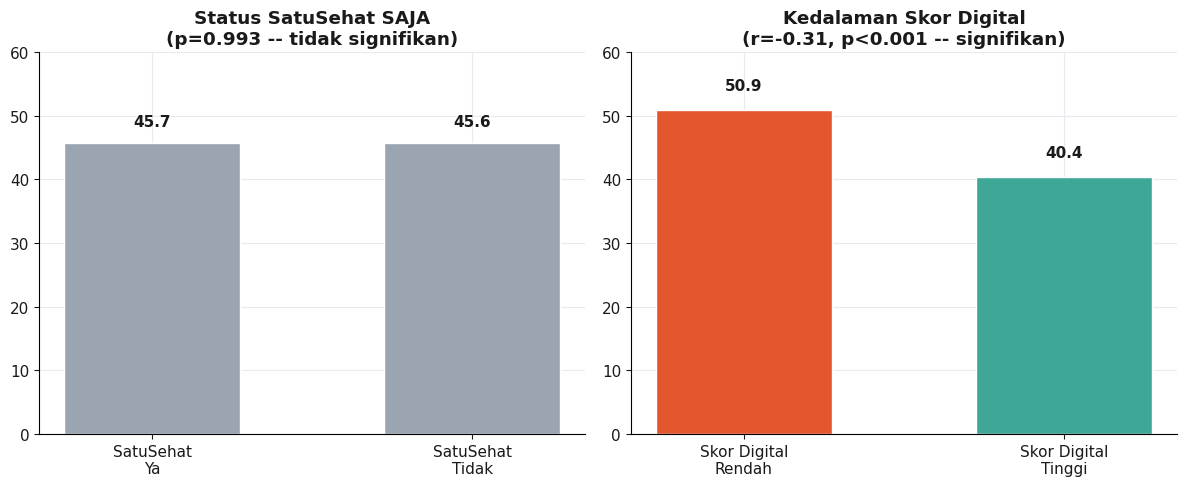

In [17]:
# Uji apakah status SatuSehat (status biner Ya/Tidak) berpengaruh terhadap waktu respons
ya = df[df['status_terhubung_satusehat']=='Ya']['rata_rata_waktu_respons_rujukan_menit']
tidak = df[df['status_terhubung_satusehat']=='Tidak']['rata_rata_waktu_respons_rujukan_menit']
t_stat, p_val = stats.ttest_ind(ya, tidak, equal_var=False)
print(f"Waktu respons -- SatuSehat 'Ya': {ya.mean():.1f} menit (n={len(ya)}) | 'Tidak': {tidak.mean():.1f} menit (n={len(tidak)})")
print(f"T-test independen: t={t_stat:.2f}, p={p_val:.5f} --> {'signifikan' if p_val<0.05 else 'TIDAK signifikan'}")

# Bandingkan dengan segmentasi skor digital kontinu (median split)
median_score = df['skor_kematangan_digital'].median()
df['segmen_digital'] = np.where(df['skor_kematangan_digital'] >= median_score, 'Tinggi', 'Rendah')
seg = df.groupby('segmen_digital')['rata_rata_waktu_respons_rujukan_menit'].mean().reindex(['Rendah','Tinggi'])
print(f"\nWaktu respons -- Skor Digital Rendah: {seg['Rendah']:.1f} menit | Tinggi: {seg['Tinggi']:.1f} menit")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
barplot_compare(axes[0], ['SatuSehat\nYa', 'SatuSehat\nTidak'], [ya.mean(), tidak.mean()],
                 colors=[GRAY, GRAY], title=f'Status SatuSehat SAJA\n(p={p_val:.3f} -- tidak signifikan)', ylim=(0, 60))
barplot_compare(axes[1], ['Skor Digital\nRendah', 'Skor Digital\nTinggi'], seg.values,
                 colors=[CORAL, GREEN], title=f'Kedalaman Skor Digital\n(r={r_resp:.2f}, p<0.001 -- signifikan)', ylim=(0, 60))
plt.tight_layout(); plt.show()

**Insight kunci (paling tajam di analisis ini):**
- Status "terhubung SatuSehat" (biner) **tidak berpengaruh signifikan** terhadap waktu respons rujukan (p=0.993 — 45.7 vs 45.6 menit, praktis nol beda).
- Yang berpengaruh signifikan justru **kedalaman transformasi digital** (skor kematangan digital kontinu, r=-0.31, p<0.001).
- RS bisa "terhubung" SatuSehat secara administratif tanpa benar-benar matang secara digital — status integrasi formal ≠ efektivitas operasional riil.
- **Implikasi kebijakan:** mengejar target "% RS terhubung" tanpa mendorong kedalaman implementasi berisiko tidak menghasilkan dampak operasional yang diharapkan.

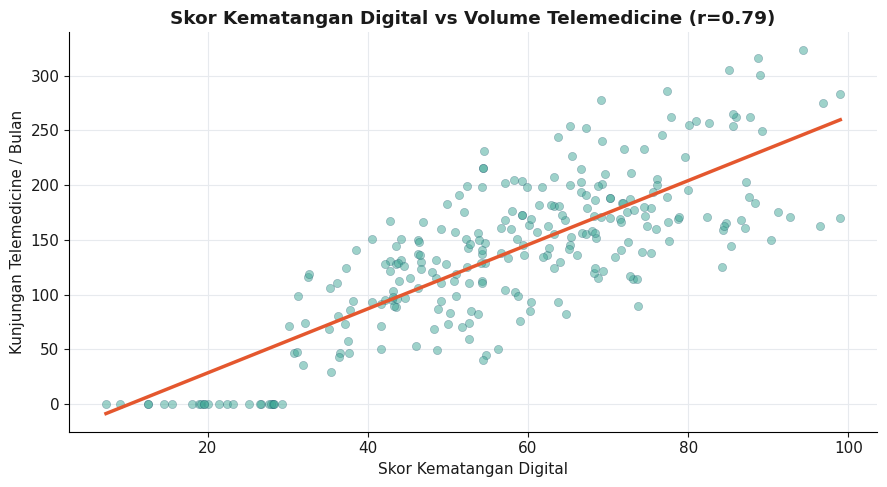

In [18]:
r_tele, p_tele = scatter_with_corr(
    sub3['skor_kematangan_digital'], sub3['kunjungan_telemedicine_per_bulan'],
    xlabel='Skor Kematangan Digital', ylabel='Kunjungan Telemedicine / Bulan',
    title='Skor Kematangan Digital vs Volume Telemedicine', color=GREEN)

**Insight:** Korelasi skor digital dengan volume telemedicine **sangat kuat** (r=0.79) — jauh lebih kuat dibanding korelasinya dengan waktu respons rujukan (r=-0.31). Transformasi digital paling terasa dampaknya pada **kanal layanan baru (telemedicine)**, bukan langsung memangkas proses rujukan lama yang mungkin masih bergantung pada faktor non-digital (SDM medis, birokrasi rujukan berjenjang).

In [19]:
r_bor, p_bor = stats.pearsonr(df['skor_kematangan_digital'], df['tingkat_keterisian_tempat_tidur_persen'])
print(f"Korelasi skor digital vs BOR (tingkat keterisian tempat tidur): r={r_bor:.3f}, p={p_bor:.4f}")

Korelasi skor digital vs BOR (tingkat keterisian tempat tidur): r=0.030, p=0.6217


**Insight (temuan null yang memperkuat pola di atas):** Skor kematangan digital **sama sekali tidak berkorelasi** dengan BOR (r≈0.03, p=0.62) — transformasi digital tidak secara langsung memengaruhi kapasitas fisik rumah sakit. Dampaknya konsisten terkonsentrasi pada proses dan kanal layanan (waktu respons, telemedicine), bukan pada kapasitas struktural seperti jumlah tempat tidur terisi.

## 5. Pilar C — Identifikasi Bottleneck ("Inefisiensi Ganda")

**Pertanyaan:** RS mana yang mengalami skor digital rendah **sekaligus** beban operasional tinggi — kandidat prioritas intervensi?

In [20]:
# Indeks Beban Operasional: komposit z-score dari BOR, waktu respons, dan LOS
df['z_bor'] = stats.zscore(df['tingkat_keterisian_tempat_tidur_persen'])
df['z_respons'] = stats.zscore(df['rata_rata_waktu_respons_rujukan_menit'])
df['z_los'] = stats.zscore(df['rata_rata_lama_rawat_hari'])
df['beban_operasional_index'] = (df['z_bor'] + df['z_respons'] + df['z_los']) / 3

median_beban = df['beban_operasional_index'].median()
df['segmen_beban'] = np.where(df['beban_operasional_index'] >= median_beban, 'Tinggi', 'Rendah')

inefisiensi_ganda = df[(df['segmen_digital']=='Rendah') & (df['segmen_beban']=='Tinggi')]
print(f"RS 'Inefisiensi Ganda': {len(inefisiensi_ganda)} dari {len(df)} RS ({len(inefisiensi_ganda)/len(df)*100:.1f}%)")

RS 'Inefisiensi Ganda': 78 dari 276 RS (28.3%)


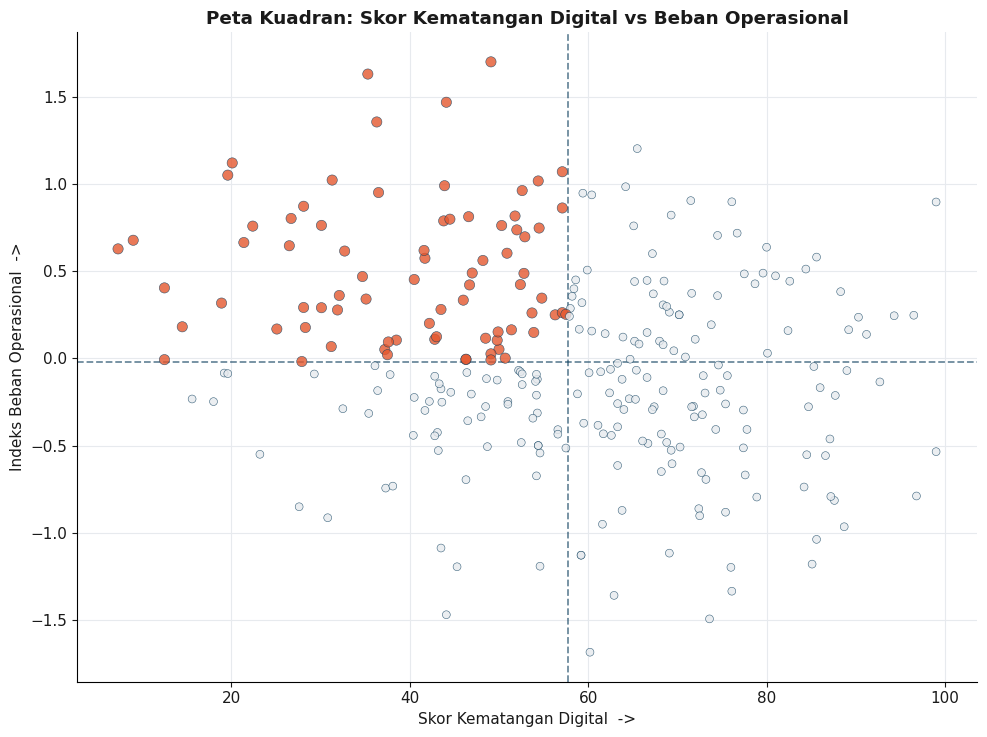

In [21]:
fig, ax = plt.subplots(figsize=(10, 7.5))
is_bottleneck = (df['segmen_digital']=='Rendah') & (df['segmen_beban']=='Tinggi')
colors_map = np.where(is_bottleneck, CORAL, LIGHTGRAY)
sizes_map = np.where(is_bottleneck, 55, 32)
ax.scatter(df['skor_kematangan_digital'], df['beban_operasional_index'], s=sizes_map, alpha=0.8,
           color=colors_map, edgecolor=NAVY, linewidth=0.4, zorder=3)
ax.axvline(median_score, color=NAVY, linestyle='--', linewidth=1.3, alpha=0.6)
ax.axhline(median_beban, color=NAVY, linestyle='--', linewidth=1.3, alpha=0.6)
ax.set_title('Peta Kuadran: Skor Kematangan Digital vs Beban Operasional', fontweight='bold')
ax.set_xlabel('Skor Kematangan Digital  ->'); ax.set_ylabel('Indeks Beban Operasional  ->')
plt.tight_layout(); plt.show()

In [22]:
order = ['A','B','C','D']
prop_kelas = df.groupby('kelas_rumah_sakit').apply(lambda g: is_bottleneck[g.index].mean()*100).reindex(order)
prop_own = df.groupby('kepemilikan').apply(lambda g: is_bottleneck[g.index].mean()*100).sort_values(ascending=False)
print("Proporsi (%) inefisiensi ganda per kelas RS:")
print(prop_kelas.round(1))
print("\nProporsi (%) inefisiensi ganda per kepemilikan:")
print(prop_own.round(1))

Proporsi (%) inefisiensi ganda per kelas RS:
kelas_rumah_sakit
A    12.5
B    23.3
C    29.2
D    35.1
dtype: float64

Proporsi (%) inefisiensi ganda per kepemilikan:
kepemilikan
Swasta               31.2
Pemerintah Daerah    29.7
TNI/POLRI            21.4
Pemerintah Pusat     20.8
BUMN                 18.2
dtype: float64


**Insight:** RS **kelas D** paling rentan (35.1% masuk kategori inefisiensi ganda) dibanding kelas A (12.5%) — pola gradasi yang jelas mengikuti kelas RS. Dari sisi kepemilikan, **Swasta** (31.2%) dan **Pemerintah Daerah** (29.7%) paling banyak terdampak, jauh di atas **BUMN** (18.2%) dan **Pemerintah Pusat** (20.8%).

In [23]:
comp_cols = ['jumlah_staf_it','anggaran_it_tahunan_juta_rupiah','jumlah_perangkat_iot','skor_kematangan_digital',
             'tingkat_keterisian_tempat_tidur_persen','rata_rata_waktu_respons_rujukan_menit','rata_rata_lama_rawat_hari']
comp = df.copy()
comp['grup'] = np.where(is_bottleneck, 'Inefisiensi Ganda', 'Lainnya')
print(comp.groupby('grup')[comp_cols].mean().round(2).T)

grup                                    Inefisiensi Ganda  Lainnya
jumlah_staf_it                                       2.97     4.77
anggaran_it_tahunan_juta_rupiah                     87.08   133.17
jumlah_perangkat_iot                                24.64    36.56
skor_kematangan_digital                             39.94    63.74
tingkat_keterisian_tempat_tidur_persen              72.22    66.22
rata_rata_waktu_respons_rujukan_menit               58.85    40.47
rata_rata_lama_rawat_hari                            4.92     3.89


In [24]:
inefisiensi_ganda2 = inefisiensi_ganda.copy()
inefisiensi_ganda2['rank_score'] = (-inefisiensi_ganda2['skor_kematangan_digital'].rank()) + inefisiensi_ganda2['beban_operasional_index'].rank()
top10 = inefisiensi_ganda2.sort_values('rank_score', ascending=False).head(10)[
    ['id_rumah_sakit','nama_rumah_sakit','provinsi','kelas_rumah_sakit','kepemilikan',
     'skor_kematangan_digital','tingkat_keterisian_tempat_tidur_persen','rata_rata_waktu_respons_rujukan_menit']]
top10

,id_rumah_sakit,nama_rumah_sakit,provinsi,kelas_rumah_sakit,kepemilikan,skor_kematangan_digital,tingkat_keterisian_tempat_tidur_persen,rata_rata_waktu_respons_rujukan_menit
222,RS0223,RS Permata Bunda 2,Nusa Tenggara Barat,C,Pemerintah Pusat,20.1,78.6,81.6
201,RS0202,RS Bhakti Husada 7,Sulawesi Tenggara,D,Swasta,19.6,57.0,105.3
227,RS0228,RS Permata Bunda 7,Nusa Tenggara Barat,D,Swasta,9.0,66.3,83.4
248,RS0249,RS Citra Medika 4,Maluku Utara,C,Swasta,28.1,88.7,56.8
199,RS0200,RSUD Permata Bunda 5,Sulawesi Tenggara,B,Pemerintah Daerah,35.3,66.0,81.1
230,RS0231,RS Bhakti Husada 2,Nusa Tenggara Timur,B,Swasta,31.3,80.0,111.2
164,RS0165,RS Karya Insani 5,Kalimantan Utara,C,Swasta,7.3,81.2,60.1
168,RS0169,RS Harapan Bangsa 9,Kalimantan Utara,D,Swasta,26.7,82.0,50.8
258,RS0259,RS Bhakti Husada 8,Papua,D,BUMN,36.3,91.6,70.1
167,RS0168,RS Sejahtera 8,Kalimantan Utara,C,Pemerintah Pusat,22.4,64.9,75.0


**Insight:** RS "inefisiensi ganda" dibanding RS lainnya, secara rata-rata:
- Staf IT **38% lebih sedikit** (2.97 vs 4.77 orang)
- Anggaran IT **35% lebih kecil** (Rp87 juta vs Rp133 juta)
- BOR **6.0 poin lebih tinggi**, waktu respons rujukan **45% lebih lambat** (58.9 vs 40.5 menit)

Ini bukan kebetulan — kekurangan sumber daya digital berjalan beriringan dengan beban operasional yang lebih berat, membentuk lingkaran yang saling memperburuk.

## 5b. Analisis Tambahan — Disparitas Wilayah (Barat vs Timur Indonesia)

Saat menelusuri karakteristik geografis dari 10 RS bottleneck terparah di atas, seluruhnya ternyata berasal dari provinsi di luar Jawa-Sumatra-Bali. Ini mendorong analisis lebih lanjut: apakah ada pola disparitas wilayah yang lebih besar dari disparitas kelas/kepemilikan?

In [25]:
wilayah_barat = ['DKI Jakarta','Jawa Barat','Jawa Tengah','DI Yogyakarta','Jawa Timur','Banten',
                  'Bali','Sumatera Utara','Sumatera Barat','Riau','Kepulauan Riau','Jambi',
                  'Sumatera Selatan','Bengkulu','Lampung','Bangka Belitung','Aceh']
df['wilayah'] = df['provinsi'].apply(lambda x: 'Barat' if x in wilayah_barat else 'Timur')

wil_summary = df.groupby('wilayah').apply(lambda g: pd.Series({
    'n_RS': len(g),
    'n_bottleneck': is_bottleneck[g.index].sum(),
    'pct_bottleneck': is_bottleneck[g.index].mean()*100,
    'skor_digital_mean': g['skor_kematangan_digital'].mean(),
    'waktu_respons_mean': g['rata_rata_waktu_respons_rujukan_menit'].mean(),
}))
print(wil_summary.round(2))

# Uji chi-square: wilayah vs status inefisiensi ganda
ct = pd.crosstab(df['wilayah'], is_bottleneck)
chi2, p_chi2, dof, exp = stats.chi2_contingency(ct)
print(f"\nChi-square (wilayah vs inefisiensi ganda): chi2={chi2:.2f}, p={p_chi2:.2e}")

# Uji-t: skor digital, anggaran IT, waktu respons by wilayah
b = df[df['wilayah']=='Barat']['skor_kematangan_digital']; t = df[df['wilayah']=='Timur']['skor_kematangan_digital']
t_skor, p_skor = stats.ttest_ind(b, t, equal_var=False)
print(f"Skor digital -- Barat: {b.mean():.1f} | Timur: {t.mean():.1f} | t={t_skor:.2f}, p={p_skor:.2e}")

sub_w = df.dropna(subset=['anggaran_it_tahunan_juta_rupiah'])
b2 = sub_w[sub_w['wilayah']=='Barat']['anggaran_it_tahunan_juta_rupiah']; t2 = sub_w[sub_w['wilayah']=='Timur']['anggaran_it_tahunan_juta_rupiah']
t_ang, p_ang = stats.ttest_ind(b2, t2, equal_var=False)
print(f"Anggaran IT   -- Barat: Rp{b2.mean():.1f}jt | Timur: Rp{t2.mean():.1f}jt | t={t_ang:.2f}, p={p_ang:.2e}")

b3 = df[df['wilayah']=='Barat']['rata_rata_waktu_respons_rujukan_menit']; t3 = df[df['wilayah']=='Timur']['rata_rata_waktu_respons_rujukan_menit']
t_resp, p_resp_w = stats.ttest_ind(b3, t3, equal_var=False)
print(f"Waktu respons -- Barat: {b3.mean():.1f} menit | Timur: {t3.mean():.1f} menit | t={t_resp:.2f}, p={p_resp_w:.2e}")

top10_wilayah = df[df['id_rumah_sakit'].isin(top10['id_rumah_sakit'])]['wilayah'].value_counts()
print("\nSebaran wilayah pada Top 10 RS bottleneck terparah:")
print(top10_wilayah)

          n_RS  n_bottleneck  pct_bottleneck  skor_digital_mean  waktu_respons_mean
wilayah                                                                            
Barat    127.0          15.0           11.81              67.66               39.92
Timur    149.0          63.0           42.28              47.94               50.56

Chi-square (wilayah vs inefisiensi ganda): chi2=29.91, p=4.52e-08
Skor digital -- Barat: 67.7 | Timur: 47.9 | t=10.20, p=6.41e-21
Anggaran IT   -- Barat: Rp140.7jt | Timur: Rp102.2jt | t=8.03, p=3.31e-14
Waktu respons -- Barat: 39.9 menit | Timur: 50.6 menit | t=-4.26, p=2.84e-05

Sebaran wilayah pada Top 10 RS bottleneck terparah:
wilayah
Timur    10
Name: count, dtype: int64


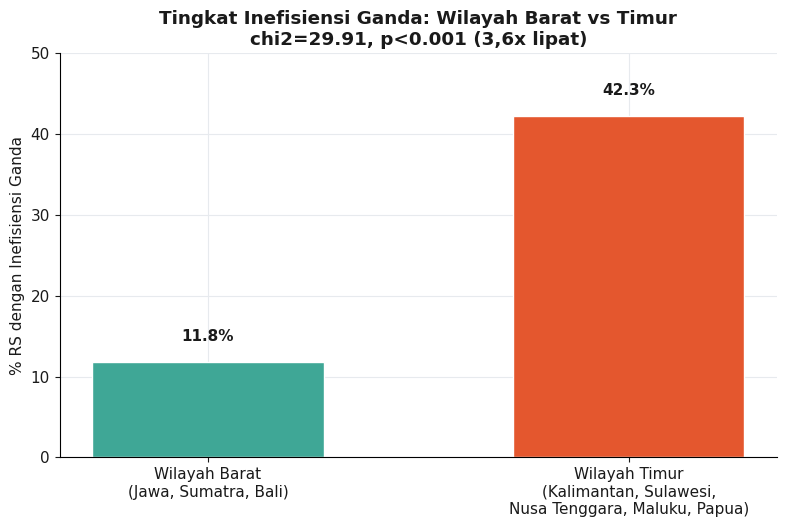

In [26]:
fig, ax = plt.subplots(figsize=(8, 5.4))
vals = [is_bottleneck[df['wilayah']=='Barat'].mean()*100, is_bottleneck[df['wilayah']=='Timur'].mean()*100]
barplot_compare(ax, ['Wilayah Barat\n(Jawa, Sumatra, Bali)', 'Wilayah Timur\n(Kalimantan, Sulawesi,\nNusa Tenggara, Maluku, Papua)'],
                 vals, colors=[GREEN, CORAL],
                 title='Tingkat Inefisiensi Ganda: Wilayah Barat vs Timur\nchi2=29.91, p<0.001 (3,6x lipat)',
                 ylabel='% RS dengan Inefisiensi Ganda', ylim=(0, 50), value_fmt='{:.1f}%')
plt.tight_layout(); plt.show()

**Insight paling kuat secara statistik dalam analisis ini:**
- Disparitas geografis Barat-Timur jauh lebih tajam dibanding disparitas kelas atau kepemilikan RS.
- Tingkat inefisiensi ganda: wilayah **Timur 42,3%** vs **Barat 11,8%** — 3,6x lipat (chi2=29,91; p<0,001).
- Skor kematangan digital rata-rata: Barat 67,7 vs Timur 47,9 (p<0,001), berlanjut ke anggaran IT (Rp140,7jt vs Rp102,2jt) dan waktu respons (39,9 vs 50,5 menit).
- Seluruh 10 RS bottleneck terparah berasal dari wilayah Timur, dengan Kalimantan Utara menyumbang 3 dari 10 kasus.

## 6. Ringkasan Insight, Rekomendasi Strategis & Kesimpulan

### Insight Utama
1. **Kesenjangan digital terpolarisasi tajam secara geografis**, melebihi kesenjangan antar kelas atau kepemilikan RS. Skor digital rata-rata wilayah Barat 67.7 vs Timur 47.9 (p<0.001); tingkat inefisiensi ganda Timur 42.3% — 3.6x lipat Barat (11.8%, chi2=29.91, p<0.001).
2. **Kesenjangan antar kelas RS signifikan namun tidak linear** (p<0.001) — kelas B (65.4) melampaui kelas A (61.2); sementara kesenjangan antar kepemilikan TIDAK signifikan (p=0.25).
3. **Anggaran IT adalah prediktor kematangan digital terkuat** (r=0.82), jauh di atas jumlah staf (r=0.53) atau perangkat IoT (r=0.65). Ranking efisiensi konversi anggaran→skor tampak berbeda deskriptif (Pemerintah Pusat 0.67 vs BUMN 0.46 poin/juta Rp), namun **TIDAK signifikan secara statistik** (Kruskal-Wallis p≈0.17) — lihat Bagian 3 untuk detail uji dan slope regresi per kepemilikan yang justru serupa.
4. **Status integrasi formal (SatuSehat/RME) TIDAK cukup** — status biner SatuSehat tidak berkorelasi dengan waktu respons (p=0.993) maupun signifikan dengan telemedicine (p=0.089); RME juga tidak signifikan (p=0.659). Hanya skor kematangan digital kontinu yang berkorelasi signifikan dengan waktu respons (r=-0.31, p<0.001) dan telemedicine (r=0.79, p<0.001).
5. **Dampak digital jauh lebih terasa di kanal baru** — korelasi ke telemedicine (r=0.79) jauh lebih kuat dibanding ke efisiensi proses lama seperti waktu respons rujukan (r=-0.31). Skor digital bahkan sama sekali tidak berkorelasi dengan BOR (r≈0.03, p=0.62) — transformasi digital tidak memengaruhi kapasitas fisik RS.
6. **28.3% RS (78 dari 276) mengalami "inefisiensi ganda"** — rata-rata staf IT 38% lebih sedikit, anggaran IT 35% lebih kecil, BOR 6.0 poin lebih tinggi, waktu respons 45% lebih lambat dibanding RS lainnya.
7. **Risiko inefisiensi ganda terkonsentrasi pada RS kecil di wilayah Timur** — proporsi meningkat konsisten dari kelas A (12.5%) ke D (35.1%); Swasta (31.2%) & Pemerintah Daerah (29.7%) paling rentan; namun pola geografis Barat-Timur adalah yang paling tajam dari semuanya.

### Rekomendasi Strategis
1. **Prioritaskan penambahan staf IT, bukan hanya hardware, untuk RS kelas C/D dengan inefisiensi ganda.** RS di zona kritis rata-rata hanya punya ~3 staf IT — penambahan SDM lebih murah dan berdampak langsung dibanding investasi perangkat besar-besaran (mengingat jumlah staf IT tetap berkorelasi positif r=0.53 meski lebih lemah dari anggaran).
2. **Ubah KPI transformasi digital dari "status terhubung" menjadi "skor kematangan" bertingkat.** Karena status SatuSehat biner terbukti tidak berkorelasi dengan efisiensi operasional riil, kebijakan yang hanya mengejar target "% RS terhubung" berisiko tidak menghasilkan dampak. Konsorsium perlu mendorong audit kedalaman implementasi, bukan sekadar status administratif.
3. **Eksplorasi tata kelola IT lintas kepemilikan melalui pilot benchmarking, bukan replikasi langsung.** Ranking efisiensi anggaran (Pusat 0.67 vs BUMN 0.46 poin/juta Rp) TIDAK signifikan secara statistik (Kruskal-Wallis p≈0.17) — slope regresi antar kepemilikan justru serupa (0.32-0.39). Konsorsium sebaiknya menjalankan studi kualitatif/pilot kecil untuk menguji praktik tata kelola yang bisa direplikasi, bukan langsung mengasumsikan RS Pemerintah Pusat sebagai benchmark tanpa validasi lebih lanjut.
4. **Bentuk skema intervensi bertarget untuk 10 RS prioritas kritis** (lihat tabel Top 10 di atas), dengan mempertimbangkan konsentrasi geografis di wilayah Timur (khususnya Kalimantan Utara), sebagai pilot program sebelum diperluas secara nasional.

### Kesimpulan
Transformasi digital rumah sakit di Indonesia berjalan dengan progres yang jauh dari merata dan jauh dari otomatis. Anggaran IT terbukti menjadi pengungkit utama kematangan digital, namun dampaknya terhadap efisiensi operasional riil baru terasa signifikan ketika kematangan digital sudah cukup dalam — bukan sekadar status integrasi formal. Ketiga pilar analisis saling menguatkan: audit kematangan digital mengungkap kesenjangan yang lebih ditentukan oleh skala operasional dan lokasi geografis dibanding kepemilikan; evaluasi dampak operasional menunjukkan kedalaman implementasi lebih penting dari status formal; dan identifikasi bottleneck mengonfirmasi kedua pola tersebut berkumpul pada RS kecil di wilayah Indonesia Timur. Perlu dicatat bahwa analisis ini bersifat cross-sectional (korelasional, bukan kausal) dan skor kematangan digital adalah indeks komposit yang metodologi penyusunannya berada di luar cakupan studi ini. Meski demikian, konsistensi statistik di seluruh tiga pilar memberikan dasar yang kuat bagi Konsorsium untuk mengalihkan fokus kebijakan dari sekadar target "status terhubung" menjadi intervensi tepat sasaran secara kelas, kepemilikan, dan geografis.

---

## Executive Takeaways

- **Anggaran IT → prediktor terkuat kematangan digital** (r = 0,82; p<0,001), namun efisiensi konversinya timpang hingga 46% antar kepemilikan.
- **Status SatuSehat saja TIDAK meningkatkan efisiensi operasional** (p=0,993) — yang berpengaruh adalah kedalaman skor kematangan digital (r=-0,31; p<0,001).
- **28,3% RS (78 dari 276) mengalami inefisiensi ganda** — skor digital rendah sekaligus beban operasional tinggi.
- **Prioritas intervensi: RS kelas C/D, terutama di wilayah Indonesia Timur** — tingkat inefisiensi ganda di sana 42,3%, 3,6x lipat wilayah Barat (11,8%; chi2=29,91, p<0,001).